In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp

def graficar_par(x1, y1, x2, y2, color1):   #funcion para graficar
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))
    
    ax1.plot(x1, y1, color=color1)
    ax1.set_title("Señal")
    ax1.set_xlabel("Muestras")
    ax1.set_ylabel("Amplitud [V]")
    ax1.grid(True)
    
    ax2.plot(x2, y2, color=color1)
    ax2.set_title("Espectro")
    ax2.set_xlabel("Frecuencia")
    ax2.set_ylabel("Amplitud [dB]")
    ax2.grid(True)
    ax2.set_xticks([2000,6000,10000,14000,18000])
    
    plt.tight_layout()
    plt.show()

fs = 40000  # f de muestreo
N = 1000    # muestras


vmax = np.sqrt(2)           # amplitud máxima
dc = 0                      # valor de continua
ff = 2000                   # frecuencia de la señal
ph = 0                      # fase
nn = np.arange(0,N)         # vector de muestras


tt = nn                        #tt era =nn/fs pero lo deje asi para mostrar todo en funcion de las muestras
frec= np.arange(N//2) * fs/N   #vector frecuencia

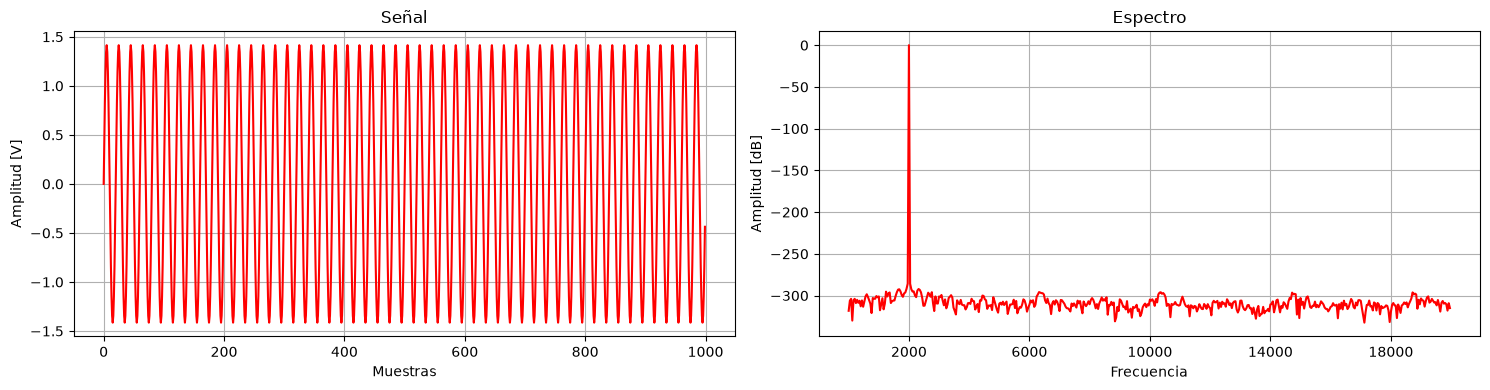

In [2]:
xx1 =   vmax * np.sin(2*np.pi* ff*nn/fs + ph)                   # sinusoidal de 2kHz y 1W
xx1tr = (1/N) * np.fft.fft(xx1)
xx1tr_db = 10 * np.log10(2*(np.abs(xx1tr[:N//2]) ) ** 2)

graficar_par(tt, xx1, frec, xx1tr_db, color1="red")

valor maximo de amplitud = 3.0102999566398108


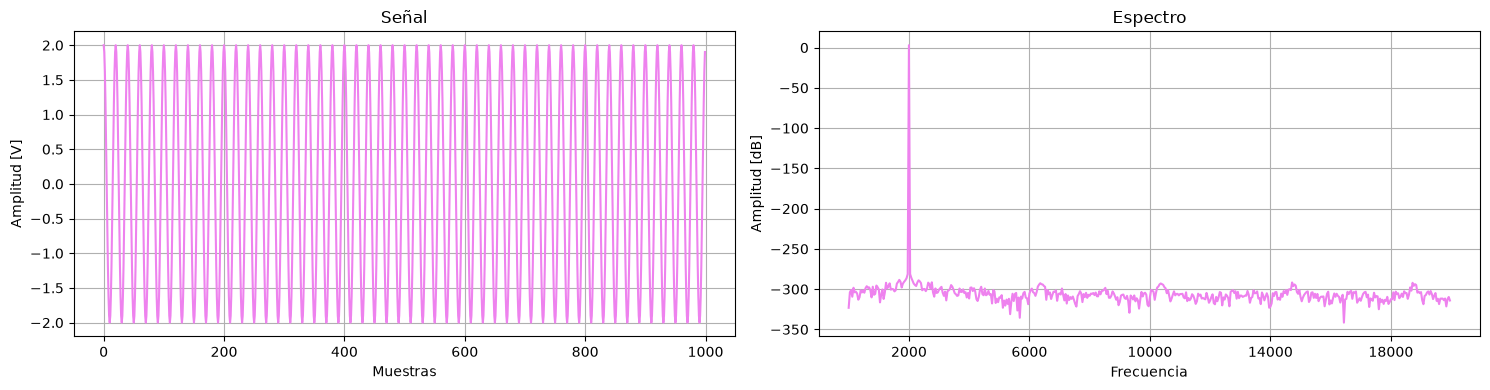

In [3]:
xx2 =      2 * np.sin(2*np.pi* ff*nn/fs + np.pi/2)              # sinusoidal de 2kHz, 2W potencia media y desfasada pi/2 
xx2tr = (1/N) * np.fft.fft(xx2)
xx2tr_db = 10 * np.log10(2*(np.abs(xx2tr[:N//2]) ) ** 2)
amp_max_xx2tr_db=np.max(xx2tr_db)
print(f"valor maximo de amplitud = {amp_max_xx2tr_db}")

graficar_par(tt, xx2, frec, xx2tr_db, color1="violet")

valor maximo de amplitud = -0.9367510777488801


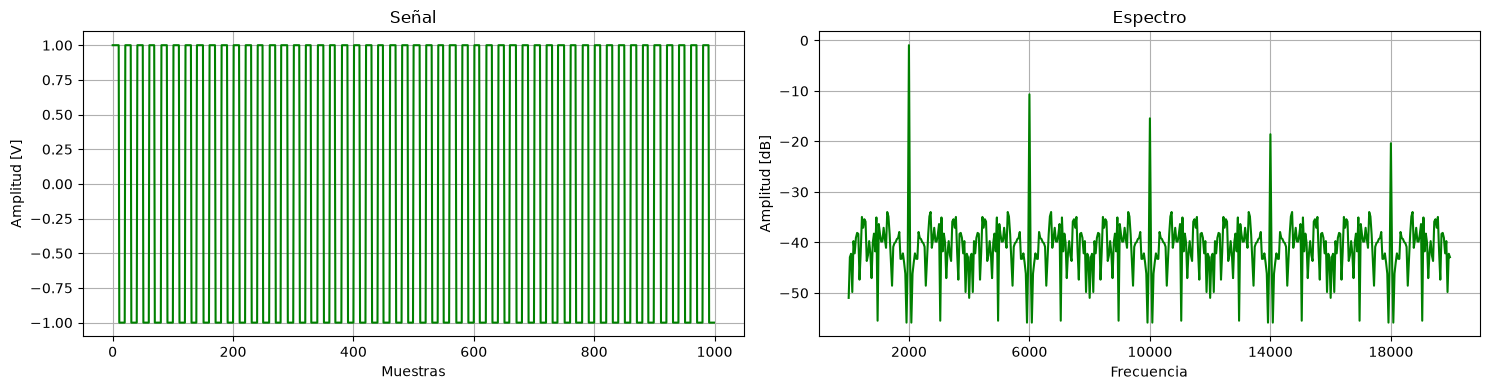

In [4]:
xx3 =      1 * sp.signal.square(2*np.pi*ff*nn/fs)               #pulso rectangular de 2kHz y 1W potencia media
xx3tr = (1/N) * np.fft.fft(xx3) 
xx3tr_db = 10 * np.log10(2*(np.abs(xx3tr[:N//2]) ) ** 2)
amp_max_xx3tr_db=np.max(xx3tr_db)
print(f"valor maximo de amplitud = {amp_max_xx3tr_db}")

graficar_par(tt, xx3, frec, xx3tr_db, color1="green")

valor medio de amplitud de ruido normal = -39.166554638924545


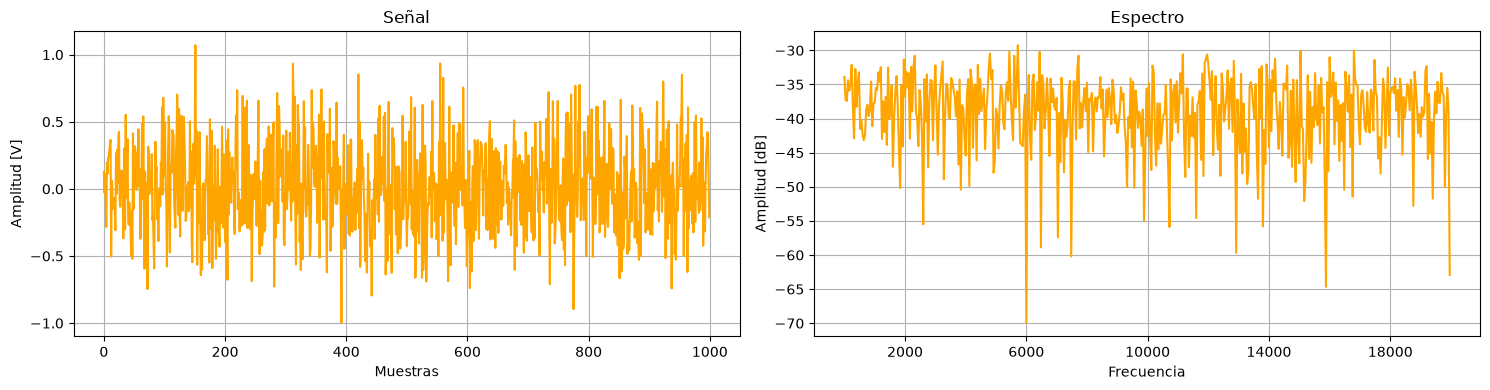

In [5]:
rrn = np.random.normal(0 , 1/np.sqrt(10) , N)                   #ruido ~N, valor medio 0V y var 0.1W
rrntr = (1/N) * np.fft.fft(rrn)
rrntr_db = 10 * np.log10(2*(np.abs(rrntr[:N//2]) ) ** 2)

mediana_rrndb = np.mean(rrntr_db)
print(f"valor medio de amplitud de ruido normal = {mediana_rrndb }")

graficar_par(tt, rrn, frec, rrntr_db, color1="orange")

valor medio de amplitud de ruido uniforme = -39.517110388251346


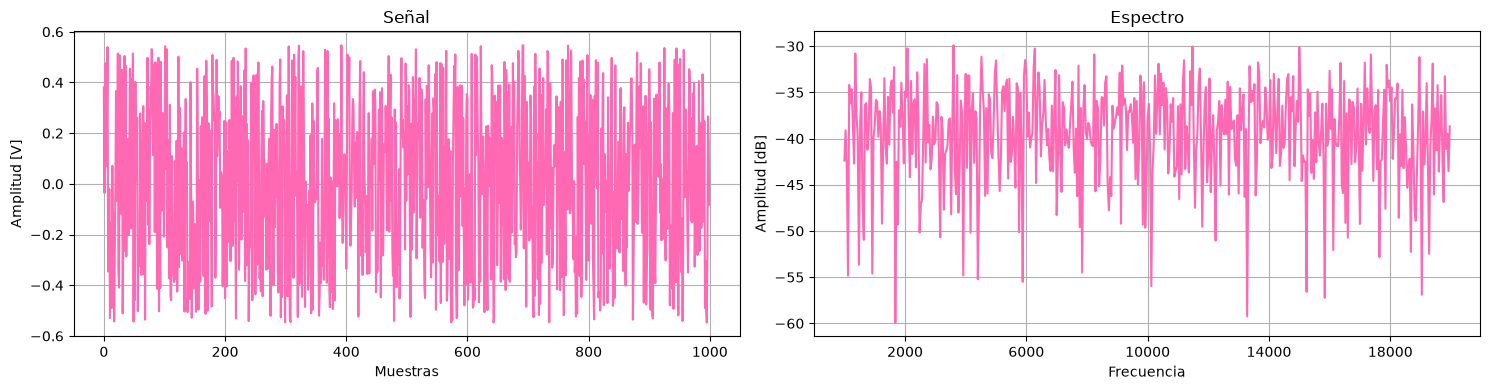

In [6]:
rru = np.random.uniform(-np.sqrt(1.2)/2 , np.sqrt(1.2)/2 , N)   #ruido ~U, valor medio 0V y var 0.1W
rrutr = (1/N) * np.fft.fft(rru)
rrutr_db = 10 * np.log10(2*(np.abs(rrutr[:N//2]) ) ** 2)

mediana_rrudb = np.mean(rrutr_db)
print(f"valor medio de amplitud de ruido uniforme = {mediana_rrudb }")

graficar_par(tt, rru, frec, rrutr_db, color1="hotpink")